In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import OneClassSVM
from scipy.stats import mode

### Step 1 — Data Loading and Standardized Domain Structuring

In [34]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("data_generated/no_shift_df.csv")

# -----------------------------
# Identify columns
# -----------------------------
feature_cols = [col for col in df.columns if col.startswith("x_")]
label_col = "y_0"
domain_col = "domain"

# -----------------------------
# Extract arrays
# -----------------------------
X = df[feature_cols].values.astype(np.float32)
y = df[label_col].values.astype(np.float32)
domains = df[domain_col].values.astype(np.int64)

# -----------------------------
# Basic sanity checks
# -----------------------------
print("Total samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of domains:", len(np.unique(domains)))
print("Label shape:", y.shape)


Total samples: 10000
Number of features: 50
Number of domains: 1
Label shape: (10000,)


Basic Statistics for y_0
-------------------------
Total samples: 10000
Mean: 0.4123348
Std: 0.34240824
Min: 4.71678e-05
Max: 0.99978906
Median: 0.33351716
25th percentile: 0.080516174
75th percentile: 0.74122506


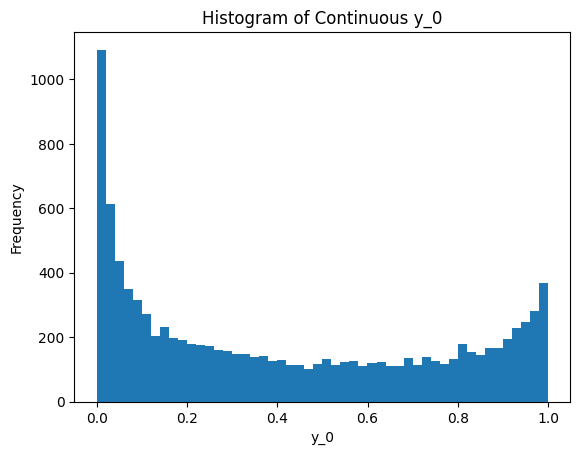

In [35]:
# Step 2: Print statistics
print("Basic Statistics for y_0")
print("-------------------------")
print("Total samples:", len(y))
print("Mean:", np.mean(y))
print("Std:", np.std(y))
print("Min:", np.min(y))
print("Max:", np.max(y))
print("Median:", np.median(y))
print("25th percentile:", np.percentile(y, 25))
print("75th percentile:", np.percentile(y, 75))

# Step 3: Plot histogram (single plot as required)
plt.figure()
plt.hist(y, bins=50)
plt.title("Histogram of Continuous y_0")
plt.xlabel("y_0")
plt.ylabel("Frequency")
plt.show()

In [36]:
# Use global median threshold
threshold = np.median(y)
y_binary = (y > threshold).astype(np.int64)

# Print balance information
print("Threshold used (median):", threshold)
print("Total samples:", len(y_binary))
print("Class 0 count:", np.sum(y_binary == 0))
print("Class 1 count:", np.sum(y_binary == 1))
print("Class 1 proportion:", np.mean(y_binary))

# Replace y with binary version if desired
y = y_binary


Threshold used (median): 0.33351716
Total samples: 10000
Class 0 count: 5000
Class 1 count: 5000
Class 1 proportion: 0.5


### Step 2 — Unified Model Training Interface (Modular Trainers)

Classical

In [37]:
def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return model


In [38]:
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


In [39]:
def train_svm(X_train, y_train):
    model = SVC(
        kernel="rbf",
        probability=True  # needed for predict_proba
    )
    model.fit(X_train, y_train)
    return model


In [40]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_nn_erm(X_train, y_train,
                 epochs=50, lr=1e-3, batch_size=128):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = SimpleNN(X_train.shape[1]).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model


Regularized

In [41]:
def train_nn_l2(X_train, y_train,
                epochs=50, lr=1e-3, batch_size=128,
                weight_decay=1e-4):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = SimpleNN(X_train.shape[1]).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay  # L2 regularization
    )

    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model


In [42]:
class DropoutNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_nn_dropout(X_train, y_train,
                     epochs=50, lr=1e-3, batch_size=128,
                     dropout_p=0.5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = DropoutNN(
        input_dim=X_train.shape[1],
        dropout_p=dropout_p
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model

Premise Based

In [ ]:
# =========================
# Train SVM Region
# =========================
def train_svm_region(x1, x2):
    if x2.ndim == 1:
        x2 = x2.reshape(-1, 1)
    X = np.hstack([x1, x2])
    svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    svm.fit(X)
    return svm


# =========================
# Differentiable SVM Wrapper
# =========================
class SVMPremise(nn.Module):
    def __init__(self, svm_model):
        super().__init__()

        self.support_vectors = torch.tensor(
            svm_model.support_vectors_, dtype=torch.float32
        )
        self.alpha = torch.tensor(
            svm_model.dual_coef_.flatten(), dtype=torch.float32
        )
        self.rho = torch.tensor(
            svm_model.intercept_[0], dtype=torch.float32
        )
        self.gamma = svm_model._gamma

    def rbf_kernel(self, X1, X2):
        sq1 = (X1**2).sum(dim=1, keepdim=True)
        sq2 = (X2**2).sum(dim=1, keepdim=True)
        sqdist = sq1 + sq2.T - 2 * X1 @ X2.T
        return torch.exp(-self.gamma * sqdist)

    def raw_decision(self, x1, x2_pred):
        X = torch.cat([x1, x2_pred], dim=1)
        K = self.rbf_kernel(self.support_vectors, X)
        f = self.alpha @ K + self.rho
        return f

    def forward(self, x1, x2_pred):
        f = self.raw_decision(x1, x2_pred)
        return torch.relu(-f)   # penalty


# =========================
# Debug Helpers
# =========================
def debug_epoch(epoch, loss, model, premise, x1_t, pred, mode):
    print(f"\nEpoch: {epoch}")
    print("Loss:", loss.item())

    if mode != "plain" and premise is not None:
        with torch.no_grad():
            penalty_vals = premise(x1_t, pred)
            raw_vals = premise.raw_decision(x1_t, pred)

            print("Penalty min:", penalty_vals.min().item())
            print("Penalty max:", penalty_vals.max().item())

            print("Raw decision min:", raw_vals.min().item())
            print("Raw decision max:", raw_vals.max().item())

    print("Gradient norms:")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(f"{name}: {param.grad.norm().item()}")

    print("-" * 50)


# =========================
# Training Function
# =========================
def train_model(x1, x2,
                mode="combined",
                lambda_premise=1e1,
                epochs=50,
                lr=1e-3,
                batch_size=128,
                debug=False):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------
    # Tensors
    # ----------------------------
    X_tensor = torch.tensor(x1, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(x2, dtype=torch.float32).unsqueeze(1).to(device)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset,
                                         batch_size=batch_size,
                                         shuffle=True)

    # ----------------------------
    # Model
    # ----------------------------
    model = SimpleNN(x1.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    # ----------------------------
    # Train SVM(s)
    # ----------------------------
    premises = None

    if mode in ["combined", "premise_only"]:

        # If domains available → multi-domain SVM
        if domains_train is not None:
            unique_domains = np.unique(domains_train)
            premises = []

            for d in unique_domains:
                mask = domains_train == d
                svm_d = train_svm_region(x1[mask], x2[mask])
                premises.append(SVMPremise(svm_d).to(device))

            n_domains = len(premises)

        # Otherwise → global SVM
        else:
            svm = train_svm_region(x1, x2)
            premises = [SVMPremise(svm).to(device)]
            n_domains = 1

    # ----------------------------
    # Training Loop
    # ----------------------------
    model.train()

    for epoch in range(epochs):

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model(xb)

            # ----------------------------
            # Plain ERM
            # ----------------------------
            if mode == "plain":
                loss = criterion(logits, yb)

            # ----------------------------
            # Combined Loss
            # ----------------------------
            elif mode == "combined":

                task_loss = criterion(logits, yb)

                total_premise_loss = 0.0

                for premise in premises:
                    # Use logits directly as predicted y
                    premise_loss = premise(xb, logits).mean()
                    total_premise_loss += premise_loss

                total_premise_loss /= n_domains

                loss = task_loss + lambda_premise * total_premise_loss

            # ----------------------------
            # Premise Only
            # ----------------------------
            elif mode == "premise_only":

                total_premise_loss = 0.0

                for premise in premises:
                    premise_loss = premise(xb, logits).mean()
                    total_premise_loss += premise_loss

                loss = total_premise_loss / n_domains

            else:
                raise ValueError("mode must be 'plain', 'combined', or 'premise_only'")

            loss.backward()
            optimizer.step()

        if debug and epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss {loss.item()}")

    return model


### Step 3 — Evaluation Protocol

In [43]:
def get_probabilities(model, X):
    
    # sklearn models
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    # torch models
    elif isinstance(model, torch.nn.Module):
        device = next(model.parameters()).device
        model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

        with torch.no_grad():
            output = model(X_tensor)

            # DANN returns tuple
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probs = torch.sigmoid(logits).cpu().numpy().flatten()

        return probs

    else:
        raise ValueError("Unsupported model type.")


In [44]:
def evaluate_random_split(train_function,
                          model_name,
                          X, y,
                          test_size=0.2,
                          threshold=0.5,
                          random_state=42,
                          **train_kwargs):

    import numpy as np
    from sklearn.model_selection import train_test_split

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # Dummy domain (single domain case)
    d_train = np.zeros(len(y_train))
    d_test = np.zeros(len(y_test))

    # Train
    model = train_function(
        X_train, y_train, #d_train,
        **train_kwargs
    )

    # Predict probabilities
    probs = get_probabilities(model, X_test)

    results = {
        "model_name": model_name,
        "y_true": y_test,
        "y_prob": probs,
        "y_pred": (probs >= threshold).astype(int),
        "domain_id": d_test,   # all zeros
        "fold_id": np.zeros(len(y_test))  # single fold
    }

    return results


In [45]:
def run_benchmark_random(models_dict,
                         X, y,
                         threshold=0.5):

    all_results = {}

    for model_name, model_info in models_dict.items():

        print(f"Running Random Split for: {model_name}")

        train_function = model_info["train_function"]
        train_kwargs = model_info.get("train_kwargs", {})

        results = evaluate_random_split(
            train_function=train_function,
            model_name=model_name,
            X=X,
            y=y,
            threshold=threshold,
            **train_kwargs
        )

        all_results[model_name] = results

    return all_results


### Step 4 — Full Benchmark Execution and Result Logging

In [ ]:
models = {
    "Logistic": {
        "train_function": train_logistic_regression
    },
    "RandomForest": {
        "train_function": train_random_forest
    },
    "SVM": {
        "train_function": train_svm
    },
    "NN_ERM": {
        "train_function": train_nn_erm
    },
    "NN_L2": {
        "train_function": train_nn_l2,
        "train_kwargs": {"weight_decay": 1e-4}
    },
    "NN_Dropout": {
        "train_function": train_nn_dropout,
        "train_kwargs": {"dropout_p": 0.5}
    },
    "NN_SVM_Global": {
        "train_function": train_model,
        "train_kwargs": {"mode": "combined", "lambda_premise": 1.0}
    },
    "NN_SVM_Only_Global": {
        "train_function": train_model, 
        "train_kwargs": {"mode": "premise_only"}
    }
}

In [47]:
all_results = run_benchmark_random(models, X, y)

Running Random Split for: Logistic
Running Random Split for: RandomForest
Running Random Split for: SVM
Running Random Split for: NN_ERM
Running Random Split for: NN_L2
Running Random Split for: NN_Dropout


In [48]:
import pickle

with open("results/no_benchmark_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Results saved to no_benchmark_results.pkl")


Results saved to no_benchmark_results.pkl
